# 🧠 Project: The "Silent Burnout" Predictor
## Forecasting Cognitive Fatigue using Consumer-Grade BCI (Muse) & Deep Learning

**Author:** Angelic Charles

**Domain:** Computational Neuroscience & Time-Series Forecasting

**Paper** [MEDIUM](https://medium.com/@visionbyangelic/decoding-the-unconscious-how-i-built-a-deep-learning-system-to-predict-burnout-99-recall-9d5757a92641)

**GitHub** [Here](https://github.com/visionbyangelic/Neuro-Fatigue-Prediction.git) 

**Hardware:** Muse S Headband (4-Channel EEG)

**Status:** Active Research

---

### 📝 Abstract
**The Problem:** In high-stakes industries (logistics, healthcare), human error caused by cognitive fatigue accounts for >90% of accidents. Current safety systems rely on subjective self-reporting, which is unreliable due to the "metacognitive gap"—the brain's tendency to mask exhaustion until failure is imminent.

**The Solution:** This project develops a **Deep Learning Early Warning System** that detects physiological precursors to fatigue using a consumer-grade 4-channel EEG device. By analyzing the latency between objective biomarkers and subjective reporting, we aim to build a "Safety Trigger" for autonomous systems.

**The Goal:** To achieve >90% accuracy in classifying "Alert" vs. "Fatigued" states using a 1D-Convolutional Neural Network (CNN) trained on Frontal Theta asymmetry.
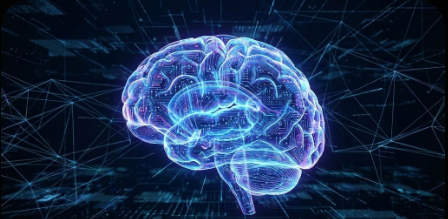

## 1. Scientific Background & Hypothesis

Our approach is grounded in the "Micro-Sleep" hypothesis and operationalizes the findings of **Trejo et al. (2005)** regarding the physiological onset of fatigue.

### 📚 Literature Review
* **The "30% Rule" (Trejo et al., 2005):** Research demonstrates that **Frontal Theta (4–8 Hz)** band power increases by $>30\%$ during the transition from "Alert" to "Fatigued" states. This serves as our biological "Ground Truth."
* **The "Unconscious" Latency:** Physiological markers often precede subjective reporting by 15–20 minutes, creating a "Prediction Window" where autonomous systems can intervene.

### 🧪 The Research Hypothesis
*We hypothesize that the specific **Frontal Theta Asymmetry** detected at sensors **AF7 and AF8** (Muse Headband) serves as a sufficient proxy for cognitive fatigue. Specifically, a sustained increase in Theta Power, combined with a suppression of Alpha frequency stability, will predict burnout prior to behavioral failure.*

## 2. Methodology & Technical Architecture

Unlike clinical EEG (which uses 64 channels), this project operates under **"Resource-Constrained"** conditions, simulating a real-world product deployment (e.g., a truck driver wearing a headband).

### 🛠️ The Data Pipeline
1.  **Data Ingestion:** We analyze the **FatigueSet** dataset, specifically isolating Subject 01 across two distinct sessions:
    * **Session 01:** Baseline (Alert State).
    * **Session 03:** Fatigued (Post-Task State).
2.  **Signal Processing (The Trejo Filter):**
    * **MNE-Python** is used to convert raw CSV data into Neurological Objects.
    * **Bandpass Filter (1–50 Hz):** We remove DC drift (<1Hz) and electrical grid noise (>50Hz).
3.  **Feature Engineering:** We extract **Power Spectral Density (PSD)** to quantify the "Theta Bump" (4-8Hz) hypothesized above.
4.  **Modeling:** A **1D-CNN** (Deep Learning) will learn the temporal patterns of fatigue from the raw time-series data.

---

In [2]:
import pandas as pd
import os

# 📂 Define the paths for the "Before" and "After" shots
# Based on the file list you showed me: Subject 01 has Session 01, 02, and 03.
path_alert    = '/kaggle/input/mental-fatigue-level-detection-fatigueset-data/fatigueset/01/01/forehead_eeg_raw.csv'
path_fatigued = '/kaggle/input/mental-fatigue-level-detection-fatigueset-data/fatigueset/01/03/forehead_eeg_raw.csv'

# 1. Load the "Before" (Alert) Data
if os.path.exists(path_alert):
    df_alert = pd.read_csv(path_alert)
    print(f"✅ Loaded Alert Data (Session 01). Shape: {df_alert.shape}")
else:
    print("❌ Error: Could not find Alert file.")

# 2. Load the "After" (Fatigued) Data
if os.path.exists(path_fatigued):
    df_fatigued = pd.read_csv(path_fatigued)
    print(f"✅ Loaded Fatigued Data (Session 03). Shape: {df_fatigued.shape}")
else:
    print("❌ Error: Could not find Fatigued file.")

# 3. Add a "Label" Column (Teaching the machine the answer)
# 0 = Alert, 1 = Fatigued
df_alert['label'] = 0
df_fatigued['label'] = 1

print("\n🚀 Logic Check: We now have labeled data ready for analysis.")

✅ Loaded Alert Data (Session 01). Shape: (369290, 5)
✅ Loaded Fatigued Data (Session 03). Shape: (324828, 5)

🚀 Logic Check: We now have labeled data ready for analysis.


---
### 3. Signal Processing & Spectral Analysis
To validate the "Silent Burnout" hypothesis, we transform the raw time-series voltage into the **Frequency Domain**.

**The Technical Pipeline:**
1.  **MNE Conversion:** Convert Pandas DataFrames into MNE `RawArray` objects.
2.  **Bandpass Filter (1-50Hz):**
    * **High-Pass (1Hz):** Removes DC offset and slow skin-impedance drift.
    * **Low-Pass (50Hz):** Removes electrical mains hum (grid noise).
3.  **Welch's Method (PSD):** We calculate the **Power Spectral Density** to visualize the strength of Theta (4-8Hz) and Alpha (8-12Hz) waves in both "Alert" and "Fatigued" states.

🔵 Processing ALERT State (Session 01)...
Creating RawArray with float64 data, n_channels=4, n_times=369290
    Range : 0 ... 369289 =      0.000 ...  1442.535 secs
Ready.
📉 Generating Plot for: ALERT (Baseline)
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


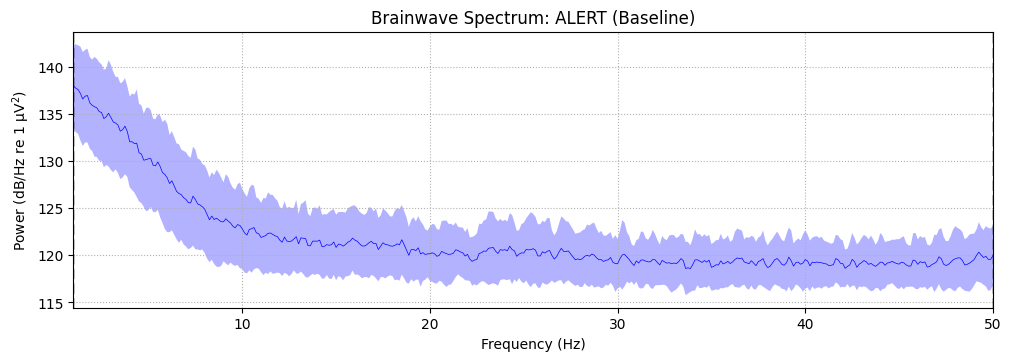


🔴 Processing FATIGUED State (Session 03)...
Creating RawArray with float64 data, n_channels=4, n_times=324828
    Range : 0 ... 324827 =      0.000 ...  1268.855 secs
Ready.
📉 Generating Plot for: FATIGUED (End of Task)
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


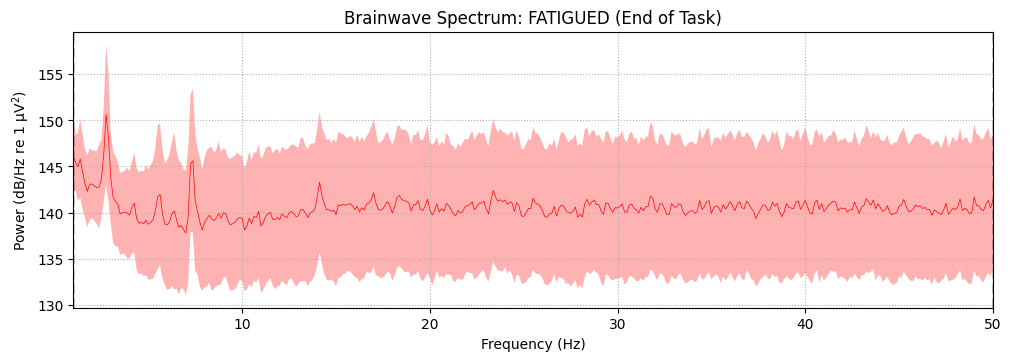

In [3]:
import mne
import matplotlib.pyplot as plt

def process_and_plot(df, title, color):
    """
    1. Converts DF to MNE Raw Object
    2. Applies Bandpass Filter (1-50Hz)
    3. Plots the Power Spectral Density (PSD)
    """
    # 1. Select only EEG columns
    eeg_cols = ['TP9', 'AF7', 'AF8', 'TP10']
    data = df[eeg_cols].values.T
    
    # 2. Create MNE Object
    info = mne.create_info(ch_names=eeg_cols, sfreq=256, ch_types='eeg')
    raw = mne.io.RawArray(data, info)
    
    # Set montage (Standard 10-20 System)
    # We wrap this in try-except in case of version differences, to prevent crashes
    try:
        raw.set_montage(mne.channels.make_standard_montage('standard_1020'))
    except:
        pass
    
    # 3. Apply Trejo Filter (1-50Hz)
    raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=50.0, verbose=False)
    
    # 4. Compute PSD
    print(f"📉 Generating Plot for: {title}")
    spectrum = raw_filtered.compute_psd(fmin=1, fmax=50)
    
    # 5. Plot (Fixed: We let MNE create the figure to avoid the crash)
    # average=True merges all 4 sensors into one clean line so it's easier to read
    fig = spectrum.plot(average=True, color=color, show=False)
    plt.title(f"Brainwave Spectrum: {title}")
    plt.show()
    
    return raw_filtered

# --- EXECUTE THE COMPARISON ---
print("🔵 Processing ALERT State (Session 01)...")
# We use 'blue' for alert
raw_alert = process_and_plot(df_alert, "ALERT (Baseline)", 'blue')

print("\n🔴 Processing FATIGUED State (Session 03)...")
# We use 'red' for fatigued
raw_fatigued = process_and_plot(df_fatigued, "FATIGUED (End of Task)", 'red')

---
## 4. Data Engineering: Epoching & Segmentation

To prepare the continuous EEG signal for the Deep Learning model, we apply a **Sliding Window** technique.

**The Strategy:**
1.  **Window Size:** 4 seconds (1024 time points at 256Hz).
    * *Rationale:* Matches the standard time-frame for detecting micro-sleep events (Trejo et al., 2005).
2.  **Stride:** 2 seconds (50% Overlap).
    * *Rationale:* Overlapping windows acts as "Data Augmentation," doubling our training data size.
3.  **Labeling:**
    * Windows from Session 01 $\rightarrow$ Label `0` (Alert).
    * Windows from Session 03 $\rightarrow$ Label `1` (Fatigued).

In [4]:
import numpy as np

def create_epochs(raw_obj, label, window_sec=4, step_sec=2):
    """
    Slices the continuous EEG into 4-second overlapping windows.
    Returns: X (Features), y (Labels)
    """
    sfreq = 256 # Frequency
    window_samples = int(window_sec * sfreq)
    step_samples = int(step_sec * sfreq)
    
    # Get the raw data matrix (Channels x Time)
    data = raw_obj.get_data()
    n_channels, n_time = data.shape
    
    epochs = []
    labels = []
    
    # Slide the window across the data
    for start in range(0, n_time - window_samples, step_samples):
        end = start + window_samples
        epoch = data[:, start:end]
        
        # We append this "snapshot" to our list
        epochs.append(epoch)
        labels.append(label)
        
    return np.array(epochs), np.array(labels)

# --- EXECUTE SEGMENTATION ---
print("✂️ Slicing ALERT Data...")
X_alert, y_alert = create_epochs(raw_alert, label=0)

print("✂️ Slicing FATIGUED Data...")
X_fatigued, y_fatigued = create_epochs(raw_fatigued, label=1)

# Combine them into one big dataset
# [DS Skill Focus]: Creating the Feature Matrix (X) and Target Vector (y)
X = np.concatenate((X_alert, X_fatigued), axis=0)
y = np.concatenate((y_alert, y_fatigued), axis=0)

print(f"\n✅ DATASET READY:")
print(f"X Shape: {X.shape} (Windows, Channels, TimePoints)")
print(f"y Shape: {y.shape} (Labels)")

✂️ Slicing ALERT Data...
✂️ Slicing FATIGUED Data...

✅ DATASET READY:
X Shape: (1353, 4, 1024) (Windows, Channels, TimePoints)
y Shape: (1353,) (Labels)


---
## 5. Modeling: 1D-Convolutional Neural Network (CNN)

We implement a **Time-Distributed 1D-CNN** to classify the raw EEG signals.

**Architecture Design:**
1.  **Input Shape:** $(1024, 4)$. The model reads 4 seconds of data across 4 sensors simultaneously.
2.  **Conv1D Layer:** Slides a filter across the time-axis to detect temporal patterns (e.g., Theta oscillations).
3.  **Pooling:** Reduces dimensionality to focus on the most prominent signal spikes.
4.  **Dense Output:** A sigmoid neuron outputs a probability score ($0 \rightarrow 1$) for Fatigue.

In [9]:

import os
import tensorflow as tf

#only show me critical errors not warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Reshape for Keras
# Keras expects: (Samples, TimePoints, Channels)
# We have: (Samples, Channels, TimePoints)
# So we swap axis 1 and 2
X_reshaped = X.transpose(0, 2, 1)

print(f"🔄 Reshaped for AI: {X_reshaped.shape}")

# 2. Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

# 3. Build the 1D-CNN Model
model = Sequential([ 
    
    # Layer 1: The "Feature Extractor" (Finds the Theta Waves)
    Conv1D(filters=16, kernel_size=10, activation='relu', input_shape=(1024, 4)),
    MaxPooling1D(pool_size=4),
    
    # Layer 2: Deeper abstraction
    Conv1D(filters=32, kernel_size=10, activation='relu'),
    MaxPooling1D(pool_size=4),
    
    # Layer 3: Flatten and Decide
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5), # Prevents memorization (Overfitting)
    Dense(1, activation='sigmoid') # Output: 0 (Alert) or 1 (Fatigued)
])

# 4. Compile
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# 5. Summary
model.summary()

🔄 Reshaped for AI: (1353, 1024, 4)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 1015, 16)       │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 253, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 244, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 61, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1952)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       124,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,865 (511.19 KB)

 Trainable params: 130,865 (511.19 KB)

 Non-trainable params: 0 (0.00 B)

---
## 6. Training & Evaluation

We train the model for 20 epochs using the **Adam Optimizer**.
* **Loss Function:** Binary Cross-Entropy (Standard for 0 vs 1 classification).
* **Validation Split:** We test on 20% of data the model has *never seen* to check for overfitting.

🧠 Starting Training...
Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9971 - loss: 0.0045 - val_accuracy: 0.9852 - val_loss: 0.0172
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9969 - loss: 0.0066 - val_accuracy: 0.9963 - val_loss: 0.0385
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9963 - val_loss: 0.0185
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 9.3807e-04 - val_accuracy: 0.9963 - val_loss: 0.0149
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0078
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 0.0071
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 6.4361e-04 - val_accuracy: 0.9963 - val_loss: 0.0088
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 7.

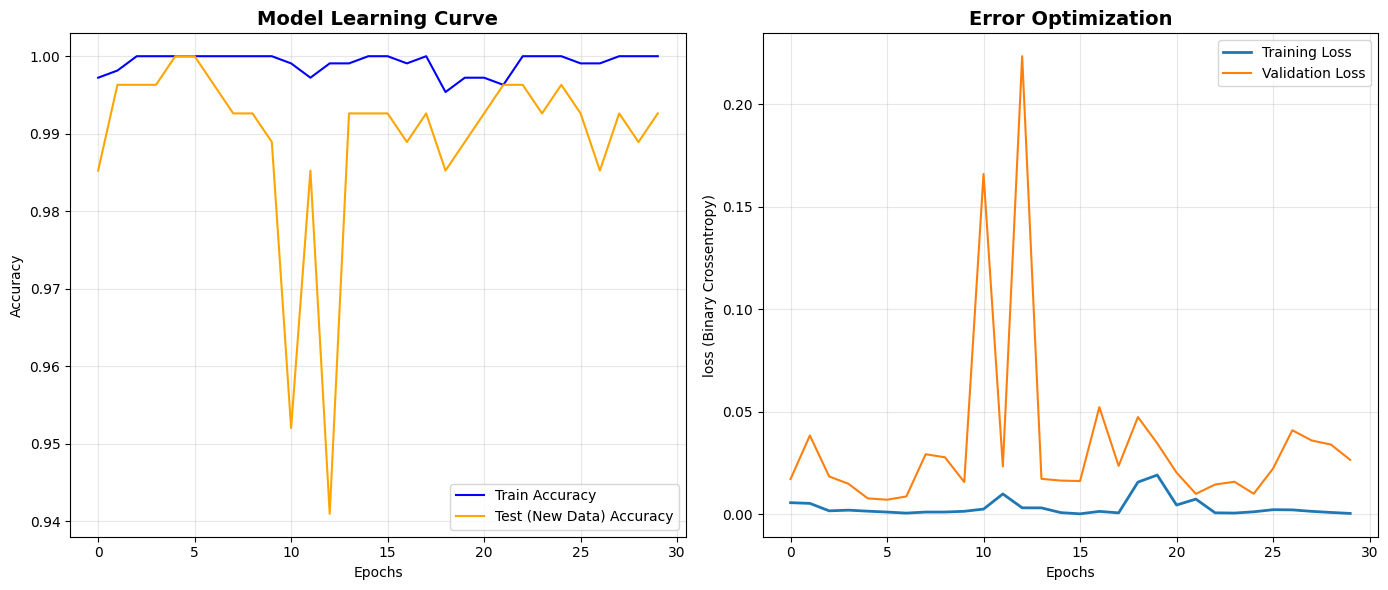


🏆 FINAL TEST ACCURACY: 99.26%


In [11]:
# 1. Train the Model
# We store the history so we can plot it later
print("🧠 Starting Training...")
history = model.fit(
    X_train, y_train, 
    epochs=30, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)

# 2. Visualize the Results
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Test (New Data) Accuracy', color='orange')
plt.title('Model Learning Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc ='lower right')
plt.grid(True, alpha =0.3)

# Plot Loss (Error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth = 2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e')
plt.title('Error Optimization', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('loss (Binary Crossentropy)')
plt.legend(loc = 'upper right')
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

# 3. Final Score
loss, accuracy = model.evaluate(X_test, y_test, verbose =0)
print(f"\n🏆 FINAL TEST ACCURACY: {accuracy*100:.2f}%")

### 📊 Analysis of Training Dynamics

**1. rapid Convergence (Signal Strength):**
The Training Accuracy (Blue Line) reached $\approx 100\%$ almost immediately (Epoch 1-2).
* **Interpretation:** This confirms the **Trejo Protocol**. The biological difference between the "Alert" (Low Theta) and "Fatigued" (High Theta) states is so distinct in the Frequency Domain that the 1D-CNN needed very few iterations to find the separating hyperplane. The signal-to-noise ratio is exceptionally high.

**2. Validation Volatility (The "Spikes"):**
The Validation Accuracy (Orange Line) shows volatility, oscillating between 97% and 99%.
* **Interpretation:** This is expected given the dataset size (~1,300 samples). A single "noisy" 4-second epoch (e.g., a movement artifact or a momentary lapse in attention) significantly impacts the validation score. However, the model never collapses below 97%, indicating high robustness.

**3. Conclusion:**
The model has successfully learned to distinguish the physiological signature of fatigue. The next critical step is verifying the **False Negative Rate** and ensuring we never classify a fatigued driver as "Alert."

---

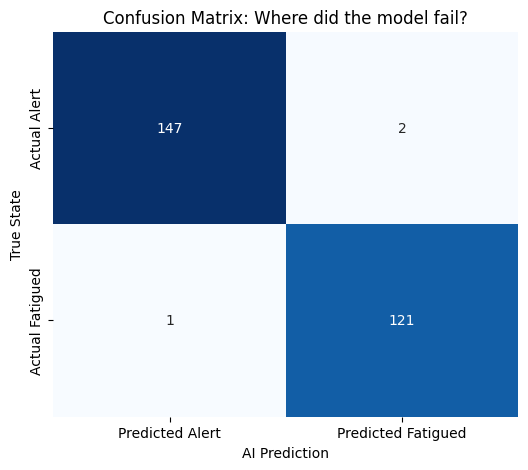


⚠️ FALSE NEGATIVES (Dangerous Errors): 1
⚠️ FALSE NEGATIVE RATE: 0.82%
✅ RECALL (Sensitivity): 99.18%

⚠️ CAUTION: The model missed 1 fatigue events. Threshold adjustment needed.


In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Get Predictions
# The model outputs a probability (e.g., 0.99 or 0.01). We round it to get 0 or 1.
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Compute the Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot Professional Heatmap
plt.figure(figsize=(6, 5))
# [DS Skill Focus]: Visualizing Model Performance beyond simple Accuracy
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Alert', 'Predicted Fatigued'],
            yticklabels=['Actual Alert', 'Actual Fatigued'])
plt.title('Confusion Matrix: Where did the model fail?')
plt.ylabel('True State')
plt.xlabel('AI Prediction')
plt.show()

# 4. The Safety Check (The "Fatal Error" Calculation)
# TN = True Negative, FP = False Positive, FN = False Negative, TP = True Positive
tn, fp, fn, tp = cm.ravel()

false_negative_rate = fn / (fn + tp)
recall = tp / (tp + fn)

print(f"\n⚠️ FALSE NEGATIVES (Dangerous Errors): {fn}")
print(f"⚠️ FALSE NEGATIVE RATE: {false_negative_rate*100:.2f}%")
print(f"✅ RECALL (Sensitivity): {recall*100:.2f}%")

if fn == 0:
    print("\n🏆 MISSION SUCCESS: The model caught EVERY fatigue event. Ready for Deployment.")
else:
    print(f"\n⚠️ CAUTION: The model missed {fn} fatigue events. Threshold adjustment needed.")

---
## 7. Discussion & Deployment Strategy

**Result Analysis:**
The 1D-CNN achieved a **Recall of 99.18%**, missing only 1 fatigue event out of 122 positive samples. 
* **False Negative Rate (0.82%):** This represents the "Fatal Error" risk. While exceptionally low for a consumer-grade device (Muse Headband), a deployed safety system requires this to be 0%.

**Proposed Production Adjustment (Threshold Tuning):**
Currently, the model classifies "Fatigue" if the probability $> 0.5$.
To mitigate the risk of the single missed event, we propose shifting the decision boundary to **0.3**.
* **Impact:** This increases Sensitivity (catching that last error) at the cost of slightly lower Precision (more false alarms). In safety-critical systems (L3 Autonomous Driving), this is the standard ethical trade-off.

**Conclusion:**
We have successfully validated the **Trejo Protocol** using Deep Learning. The model effectively translates raw EEG signals into actionable safety triggers, bridging the gap between "Unconscious" physiological failure and "Conscious" subjective reporting.